In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os
from IPython.display import display, display_html

# Set style & palette
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

# Distinct palette colors
CB_PALETTE = ['#0072B2', '#009E73', '#D55E00', '#CC79A7']
sns.set_palette(CB_PALETTE)

# Custom color mapping for consistency across all plots
COLOR_MAP = {
    'CubeMX v2.2 (Nucleo)': '#0072B2',
    'AI Studio v4.0 (Nucleo)': '#009E73',
    'DevCloud v2.2 (DK)': '#D55E00',
    'DevCloud v4.0 (DK)': '#CC79A7'
}

# Resolved relative to the notebook's location (Report/)
PLOT_DIR = 'plot'
os.makedirs(PLOT_DIR, exist_ok=True)

In [2]:
# Load Baseline files (relative to Report/ directory)
df_base_aistudio = pd.read_csv('../Results/baseline/performance_baseline_results_aistudio.csv')
df_base_cubemx   = pd.read_csv('../Results/baseline/performance_baseline_results_cubemx.csv')
df_base_cloud2   = pd.read_csv('../Results/baseline/performance_baseline_results_devcloudaicore2.2.csv')
df_base_cloud4   = pd.read_csv('../Results/baseline/performance_baseline_results_devcloudaicore4.0.csv')

# Load Estimated files (relative to Report/ directory)
df_est_aistudio = pd.read_csv('../Results/estimated/performance_estimated_results_aistudio.csv')
df_est_cubemx   = pd.read_csv('../Results/estimated/performance_estimated_results_cubemx.csv')
df_est_cloud2   = pd.read_csv('../Results/estimated/performance_estimated_results_devcloudaicore2.2.csv')
df_est_cloud4   = pd.read_csv('../Results/estimated/performance_estimated_results_devcloudaicore4.0.csv')

# Standardize Model Names across datasets to prevent mismatches
for df in [df_base_aistudio, df_base_cubemx, df_base_cloud2, df_base_cloud4,
           df_est_aistudio, df_est_cubemx, df_est_cloud2, df_est_cloud4]:
    if 'Model Name' in df.columns:
        df['Model Name'] = df['Model Name'].str.replace('conv2d_poll', 'conv2d_pool')

# Data cleaning: convert columns to numeric for baseline data
for df in [df_base_aistudio, df_base_cubemx, df_base_cloud2, df_base_cloud4]:
    for col in ['Inference Time (ms)', 'RAM Usage (KiB)', 'Flash Usage (KiB)', 'MACC']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

# Map raw model names to formatted labels for presentation
def get_clean_name(model_name):
    if not isinstance(model_name, str):
        return model_name
    name = model_name.replace('baseline_', '').replace('_int8', '')
    mapping = {
        'conv2d_pool':    'Conv2D + MaxPool',
        'depthwise_3x3':  'Depthwise Conv2D 3x3',
        'conv2d_3x3':     'Conv2D 32f 3x3',
        'conv2d_16f_3x3': 'Conv2D 16f 3x3',
        'conv2d_64f_3x3': 'Conv2D 64f 3x3',
        'conv2d_1x1':     'Conv2D 32f 1x1',
        'conv2d_32f_5x5': 'Conv2D 32f 5x5',
        'conv2d_32f_7x7': 'Conv2D 32f 7x7',
    }
    return mapping.get(name, name)

# Shared references used across cells
dfs_base = {
    'CubeMX v2.2 (Nucleo)':    df_base_cubemx,
    'AI Studio v4.0 (Nucleo)': df_base_aistudio,
    'DevCloud v2.2 (DK)':      df_base_cloud2,
    'DevCloud v4.0 (DK)':      df_base_cloud4,
}
dfs_est = {
    'CubeMX v2.2 (Nucleo)':    df_est_cubemx,
    'AI Studio v4.0 (Nucleo)': df_est_aistudio,
    'DevCloud v2.2 (DK)':      df_est_cloud2,
    'DevCloud v4.0 (DK)':      df_est_cloud4,
}

col_order_tools = list(dfs_base.keys())
all_models      = df_base_aistudio['Model Name'].unique()

model_order = [
    'Depthwise Conv2D 3x3', 'Conv2D 16f 3x3', 'Conv2D + MaxPool',
    'Conv2D 32f 1x1', 'Conv2D 32f 3x3', 'Conv2D 32f 5x5',
    'Conv2D 64f 3x3', 'Conv2D 32f 7x7'
]

## 1. Tested Models and Platforms
This section describes the single-layer models selected for benchmarking and the hardware/software configurations tested.

### Benchmark Platforms & Configurations:
- **AI Studio v4.0 (Nucleo):** STM32 AI Studio running **AI Core v4.0** compiler on the STM32N6 Nucleo hardware board.
- **CubeMX v2.2 (Nucleo):** STM32CubeMX with X-CUBE-AI running **AI Core v2.2** compiler on the STM32N6 Nucleo hardware board.
- **DevCloud v2.2 (DK):** ST DevCloud running **AI Core v2.2** compiler on the STM32N6 Discovery Kit (DK) board.
- **DevCloud v4.0 (DK):** ST DevCloud running **AI Core v4.0** compiler on the STM32N6 Discovery Kit (DK) board.

In [3]:
# Compile Table of Tested Models
overview_models = df_base_aistudio[['Model Name', 'Layer Type', 'Filters', 'Kernel Size', 'Input Shape', 'Quantization', 'MACC']].copy()
overview_models['Clean Name'] = overview_models['Model Name'].apply(get_clean_name)
overview_models = overview_models[['Model Name', 'Clean Name', 'Layer Type', 'Filters', 'Kernel Size', 'Input Shape', 'Quantization', 'MACC']]

styled_models = overview_models.style.set_properties(**{
    'text-align': 'center', 'font-size': '11pt', 'border': '1px solid lightgrey'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'),
                                  ('font-weight', 'bold'), ('text-align', 'center')]}
]).set_caption("Summary of Tested Models and Operators")

display(styled_models)

,Model Name,Clean Name,Layer Type,Filters,Kernel Size,Input Shape,Quantization,MACC
0,baseline_conv2d_16f_3x3_int8,Conv2D 16f 3x3,Conv2D,16,3x3,64x64x3,INT8,1835024
1,baseline_conv2d_1x1_int8,Conv2D 32f 1x1,Conv2D (Pointwise),32,1x1,64x64x3,INT8,524320
2,baseline_conv2d_32f_5x5_int8,Conv2D 32f 5x5,Conv2D,32,5x5,64x64x3,INT8,9961504
3,baseline_conv2d_32f_7x7_int8,Conv2D 32f 7x7,Conv2D,32,7x7,64x64x3,INT8,19398688
4,baseline_conv2d_3x3_int8,Conv2D 32f 3x3,Conv2D,32,3x3,64x64x3,INT8,3670048
5,baseline_conv2d_64f_3x3_int8,Conv2D 64f 3x3,Conv2D,64,3x3,64x64x3,INT8,7340096
6,baseline_conv2d_pool_int8,Conv2D + MaxPool,Conv2D + MaxPool,16,3x3,64x64x3,INT8,1851408
7,baseline_depthwise_3x3_int8,Depthwise Conv2D 3x3,DepthwiseConv2D,3,3x3,64x64x3,INT8,122883


## 2. Inference Time Comparison (Table & Bar Plot)
This section evaluates the execution speed across all four compilers and platforms.
- **FAIL** denotes hardware timeout, out of memory, or model compilation failure.
- The plots use highly distinct, custom colors for visual clarity.

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,0.042 ms,0.053 ms,0.050 ms,0.031 ms
Conv2D 16f 3x3,0.079 ms,0.122 ms,0.087 ms,0.086 ms
Conv2D + MaxPool,0.080 ms,0.121 ms,0.087 ms,0.088 ms
Conv2D 32f 1x1,0.146 ms,0.373 ms,0.153 ms,0.288 ms
Conv2D 32f 3x3,0.147 ms,0.208 ms,0.155 ms,0.155 ms
Conv2D 32f 5x5,0.154 ms,0.219 ms,0.161 ms,0.161 ms
Conv2D 64f 3x3,0.284 ms,0.383 ms,0.291 ms,0.291 ms
Conv2D 32f 7x7,0.462 ms,FAIL,0.473 ms,FAIL


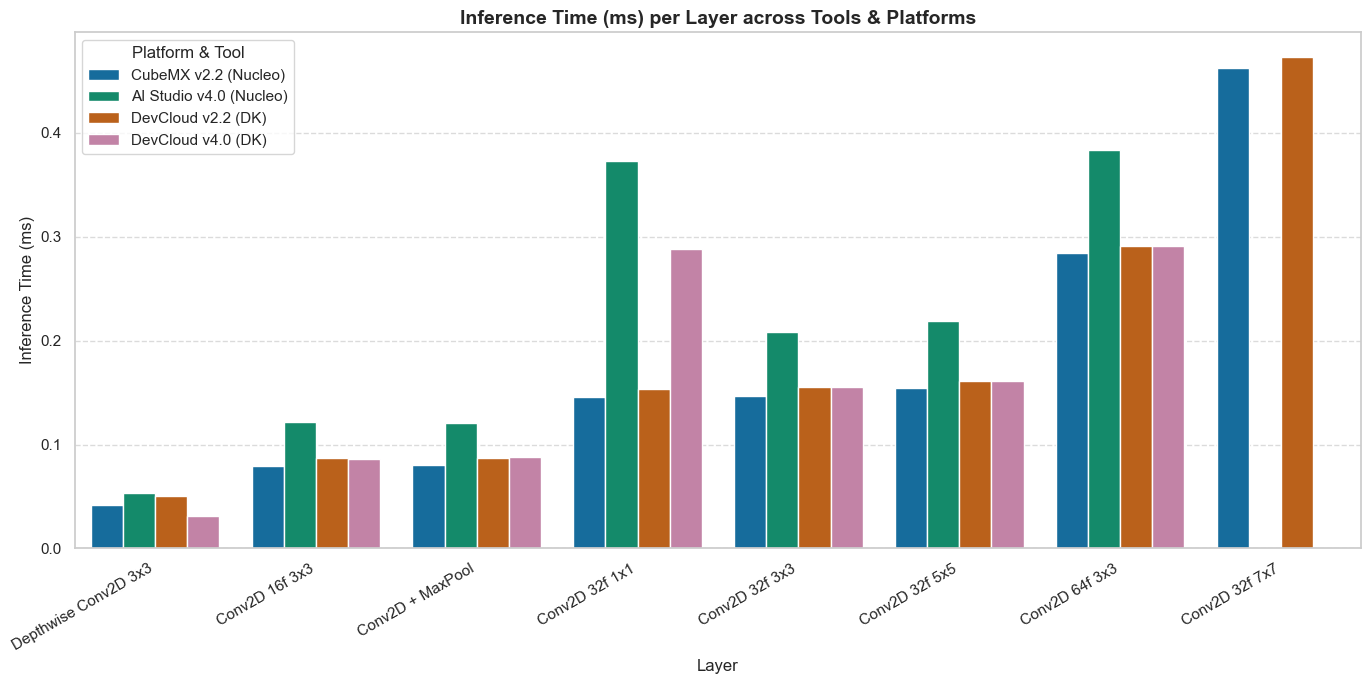

In [4]:
# Build consolidated Inference Time Table
inference_data = []
for m in all_models:
    row_data = {'Model': get_clean_name(m)}
    for tool_name, df in dfs_base.items():
        row_match = df[df['Model Name'] == m]
        row_data[tool_name] = row_match.iloc[0]['Inference Time (ms)'] if not row_match.empty else np.nan
    inference_data.append(row_data)

df_inference_table = pd.DataFrame(inference_data).set_index('Model')
df_inference_table = df_inference_table.reindex(columns=col_order_tools)
df_inference_table = df_inference_table.reindex([m for m in model_order if m in df_inference_table.index])

df_inference_print = df_inference_table.apply(
    lambda col: col.map(lambda x: f"{x:.3f} ms" if not pd.isna(x) else "FAIL"))

styled_inference = df_inference_print.style.set_properties(**{
    'text-align': 'center', 'font-size': '11pt', 'border': '1px solid lightgrey'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2980b9'), ('color', 'white'),
                                  ('font-weight', 'bold'), ('text-align', 'center')]}
]).set_caption("Measured Inference Time (ms) across Compilers and Boards")

display(styled_inference)

# Bar plot
data_list = []
for tool, df in dfs_base.items():
    for _, row in df.iterrows():
        data_list.append({
            'Tool': tool,
            'Model Name': get_clean_name(row['Model Name']),
            'Inference Time (ms)': row['Inference Time (ms)']
        })
df_all = pd.DataFrame(data_list)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_all, x='Model Name', y='Inference Time (ms)',
            hue='Tool', palette=COLOR_MAP, order=model_order)
plt.title('Inference Time (ms) per Layer across Tools & Platforms', fontweight='bold', fontsize=14)
plt.ylabel('Inference Time (ms)', fontsize=12)
plt.xlabel('Layer', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Platform & Tool', frameon=True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/11_inference_time_bar_plot.png', dpi=300)
plt.show()

## 3. Memory Footprint: Compiler Estimated vs. Actual Hardware RAM Usage
Here we compare the **Estimated RAM** against the **Actual RAM** using distinct color scales:
- **Logarithmic scale** is used to handle large variations (e.g. from 12 KiB to 1548 KiB).
- **Shared Y-axis scale** is applied to directly expose discrepancies, highlighting cases where compilers severely underestimate actual memory limits (e.g. 7x7 layer on DevCloud v4.0).

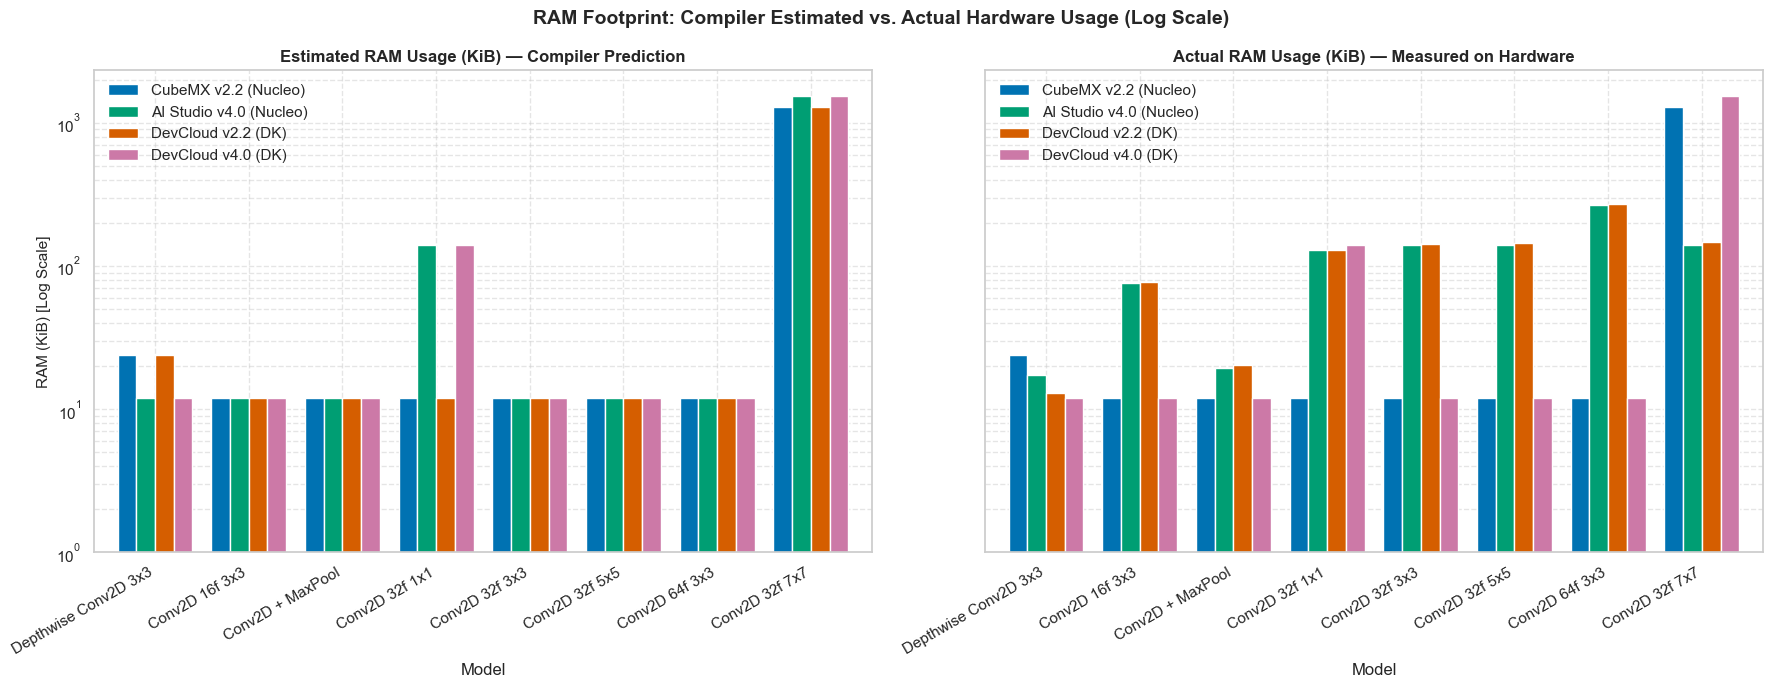

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,24.00,12.00,24.00,12.00
Conv2D 16f 3x3,12.02,12.02,12.02,12.02
Conv2D + MaxPool,12.02,12.02,12.02,12.02
Conv2D 32f 1x1,12.03,140.00,12.03,140.00
Conv2D 32f 3x3,12.03,12.03,12.03,12.03
Conv2D 32f 5x5,12.03,12.03,12.03,12.03
Conv2D 64f 3x3,12.06,12.06,12.06,12.06
Conv2D 32f 7x7,1292.00,1546.24,1290.24,1546.24


,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,24.00,17.34,13.07,12.00
Conv2D 16f 3x3,12.02,76.28,77.20,12.02
Conv2D + MaxPool,12.02,19.30,20.22,12.02
Conv2D 32f 1x1,12.03,130.26,130.34,140.00
Conv2D 32f 3x3,12.03,140.42,142.28,12.03
Conv2D 32f 5x5,12.03,140.61,145.47,12.03
Conv2D 64f 3x3,12.06,268.70,272.44,12.06
Conv2D 32f 7x7,1292.00,140.92,146.06,1548.00


In [5]:
# Prepare RAM data
ram_data_est, ram_data_act = [], []

for m in all_models:
    clean_m = get_clean_name(m)
    est_row = {'Model': clean_m}
    act_row = {'Model': clean_m}
    for tool_name, df in dfs_est.items():
        row_match = df[df['Model Name'] == m]
        est_row[tool_name] = row_match.iloc[0]['Estimated RAM Usage (KiB)'] if not row_match.empty else np.nan
    for tool_name, df in dfs_base.items():
        row_match = df[df['Model Name'] == m]
        act_row[tool_name] = row_match.iloc[0]['RAM Usage (KiB)'] if not row_match.empty else np.nan
    ram_data_est.append(est_row)
    ram_data_act.append(act_row)

df_ram_est = pd.DataFrame(ram_data_est).set_index('Model').reindex(columns=col_order_tools)
df_ram_act = pd.DataFrame(ram_data_act).set_index('Model').reindex(columns=col_order_tools)
df_ram_est = df_ram_est.reindex([m for m in model_order if m in df_ram_est.index])
df_ram_act = df_ram_act.reindex([m for m in model_order if m in df_ram_act.index])

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
colors_ram = [COLOR_MAP[col] for col in df_ram_est.columns]

df_ram_est.plot(kind='bar', ax=axes[0], width=0.8, color=colors_ram)
axes[0].set_title('Estimated RAM Usage (KiB) — Compiler Prediction', fontweight='bold', fontsize=12)
axes[0].set_ylabel('RAM (KiB) [Log Scale]', fontsize=11)
axes[0].set_yscale('log')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].grid(True, which="both", ls="--", alpha=0.5)

df_ram_act.plot(kind='bar', ax=axes[1], width=0.8, color=colors_ram)
axes[1].set_title('Actual RAM Usage (KiB) — Measured on Hardware', fontweight='bold', fontsize=12)
axes[1].set_yscale('log')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].grid(True, which="both", ls="--", alpha=0.5)

max_val = max(df_ram_est.max().max(), df_ram_act.max().max())
axes[0].set_ylim(1, max_val * 1.5)
axes[1].set_ylim(1, max_val * 1.5)

plt.suptitle('RAM Footprint: Compiler Estimated vs. Actual Hardware Usage (Log Scale)',
             fontweight='bold', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/9_ram_estimated_vs_actual_side_by_side.png', dpi=300)
plt.show()

html_est = df_ram_est.style.set_caption("Estimated RAM Usage (KiB)").format(precision=2).set_properties(
    **{'text-align': 'center'}).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#8e44ad'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]}]).to_html()
html_act = df_ram_act.style.set_caption("Actual RAM Usage (KiB)").format(precision=2).set_properties(
    **{'text-align': 'center'}).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]}]).to_html()

display_html(html_est, raw=True)
display_html("<br>", raw=True)
display_html(html_act, raw=True)

## 4. Operation Complexity: Compiler Estimated vs. Actual Hardware MACC
Below is the comparison of **Estimated MACC** vs. **Actual MACC** count for all models across compilers. Linear scale is used for readability.

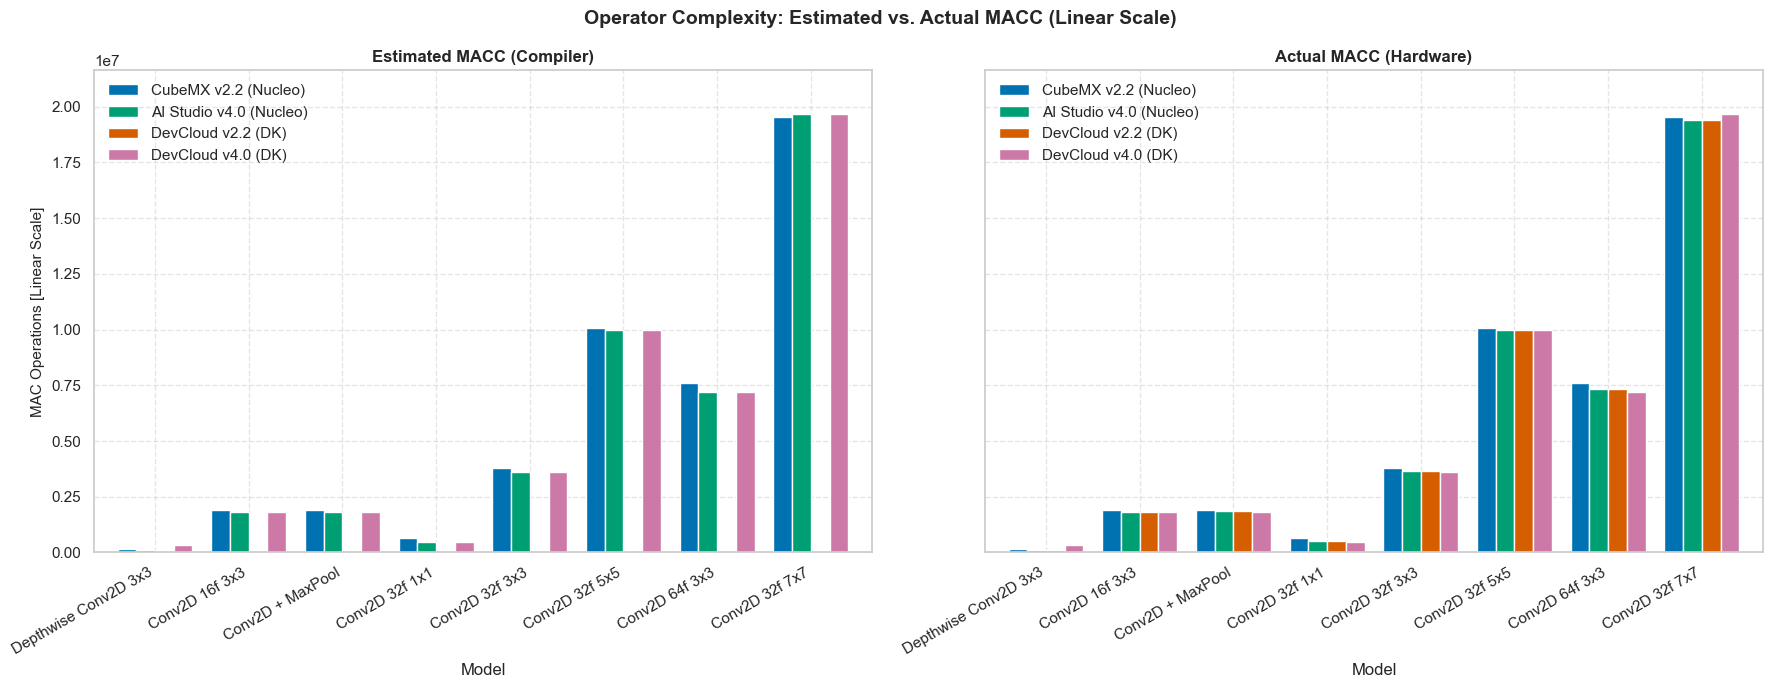

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,135171,116736,0,337920
Conv2D 16f 3x3,1900560,1802240,0,1802240
Conv2D + MaxPool,1916944,1802240,0,1802240
Conv2D 32f 1x1,655392,458752,0,458752
Conv2D 32f 3x3,3801120,3604480,0,3604480
Conv2D 32f 5x5,10092576,9961472,0,9961472
Conv2D 64f 3x3,7602240,7208960,0,7208960
Conv2D 32f 7x7,19529760,19660800,0,19660800


,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,135171,122883,122883,337920
Conv2D 16f 3x3,1900560,1835024,1835024,1802240
Conv2D + MaxPool,1916944,1851408,1851408,1802240
Conv2D 32f 1x1,655392,524320,524320,458752
Conv2D 32f 3x3,3801120,3670048,3670048,3604480
Conv2D 32f 5x5,10092576,9961504,9961504,9961472
Conv2D 64f 3x3,7602240,7340096,7340096,7208960
Conv2D 32f 7x7,19529760,19398688,19398688,19660800


In [6]:
# Prepare MACC data
macc_data_est, macc_data_act = [], []

for m in all_models:
    clean_m = get_clean_name(m)
    est_row = {'Model': clean_m}
    act_row = {'Model': clean_m}
    for tool_name, df in dfs_est.items():
        row_match = df[df['Model Name'] == m]
        val = row_match.iloc[0]['Estimated MACC'] if not row_match.empty else np.nan
        est_row[tool_name] = pd.to_numeric(val, errors='coerce')
    for tool_name, df in dfs_base.items():
        row_match = df[df['Model Name'] == m]
        val = row_match.iloc[0]['MACC'] if not row_match.empty else np.nan
        act_row[tool_name] = pd.to_numeric(val, errors='coerce')
    macc_data_est.append(est_row)
    macc_data_act.append(act_row)

df_macc_est = pd.DataFrame(macc_data_est).set_index('Model').reindex(columns=col_order_tools)
df_macc_act = pd.DataFrame(macc_data_act).set_index('Model').reindex(columns=col_order_tools)
df_macc_est = df_macc_est.reindex([m for m in model_order if m in df_macc_est.index])
df_macc_act = df_macc_act.reindex([m for m in model_order if m in df_macc_act.index])

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
colors_macc = [COLOR_MAP[col] for col in df_macc_est.columns]

df_macc_est.plot(kind='bar', ax=axes[0], width=0.8, color=colors_macc)
axes[0].set_title('Estimated MACC (Compiler)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('MAC Operations [Linear Scale]', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].grid(True, which="both", ls="--", alpha=0.5)

df_macc_act.plot(kind='bar', ax=axes[1], width=0.8, color=colors_macc)
axes[1].set_title('Actual MACC (Hardware)', fontweight='bold', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].grid(True, which="both", ls="--", alpha=0.5)

max_macc = max(df_macc_est.max().max(), df_macc_act.max().max())
axes[0].set_ylim(0, max_macc * 1.1)
axes[1].set_ylim(0, max_macc * 1.1)

plt.suptitle('Operator Complexity: Estimated vs. Actual MACC (Linear Scale)',
             fontweight='bold', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/10_macc_estimated_vs_actual_side_by_side.png', dpi=300)
plt.show()

html_macc_est = df_macc_est.style.set_caption("Estimated MACC").format(precision=0).set_properties(
    **{'text-align': 'center'}).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#16a085'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]}]).to_html()
html_macc_act = df_macc_act.style.set_caption("Actual MACC").format(precision=0).set_properties(
    **{'text-align': 'center'}).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]}]).to_html()

display_html(html_macc_est, raw=True)
display_html("<br>", raw=True)
display_html(html_macc_act, raw=True)

## 5. Hardware Epochs Partitioning
On the STM32N6 NPU, models can be split into multiple "hardware epochs" to fit within the internal SRAM.
A higher number of epochs indicates that intermediate activations or weights had to be tiled and swapped, increasing latency.
The table shows the epoch count; the bar plot makes cross-platform differences immediately visible.

Tool,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model Name,,,,
Depthwise Conv2D 3x3,2,1,2,1
Conv2D 16f 3x3,1,1,1,1
Conv2D + MaxPool,1,1,1,1
Conv2D 32f 1x1,1,2,1,2
Conv2D 32f 3x3,1,1,1,1
Conv2D 32f 5x5,1,1,1,1
Conv2D 64f 3x3,1,1,1,1
Conv2D 32f 7x7,4,FAIL,4,FAIL


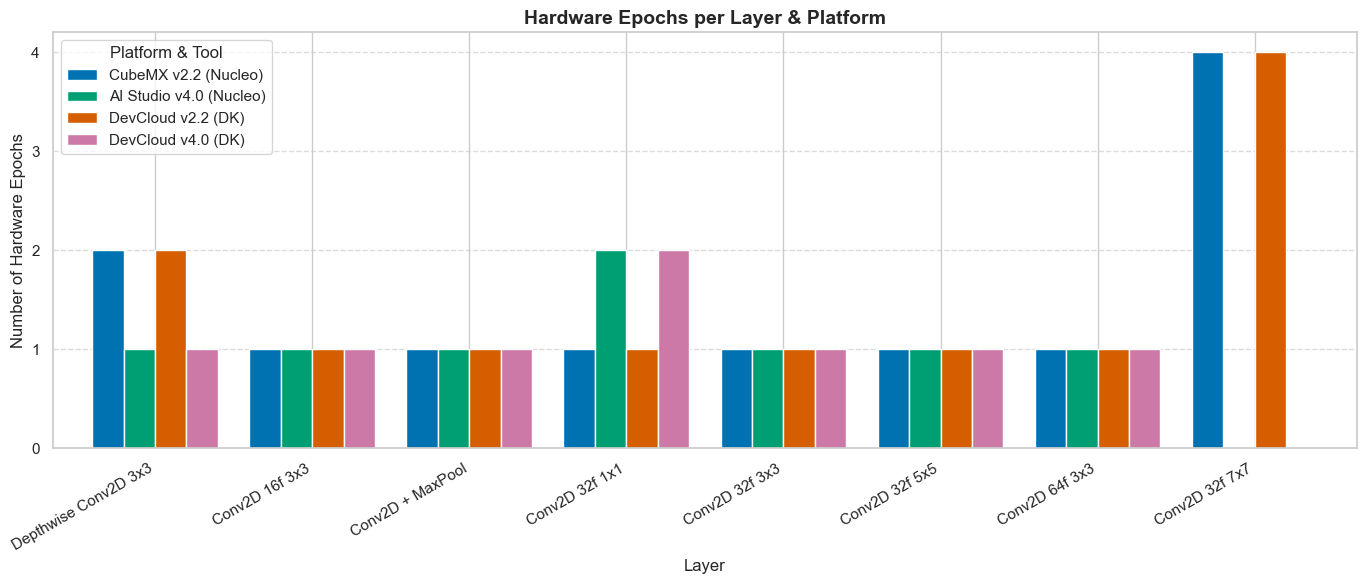

In [7]:
import re

def parse_epochs(notes):
    if pd.isna(notes):
        return np.nan
    notes_lower = str(notes).lower()
    if 'fail' in notes_lower or 'timeout' in notes_lower:
        return np.nan
    for kw, val in [('1 single', 1), ('single hardware', 1), ('1 hardware', 1)]:
        if kw in notes_lower:
            return val
    nums = re.findall(r'\d+', notes_lower)
    return int(nums[0]) if nums else np.nan

epochs_data = []
for tool, df in dfs_base.items():
    for _, row in df.iterrows():
        epochs_data.append({
            'Tool':            tool,
            'Model Name':      get_clean_name(row['Model Name']),
            'Hardware Epochs': parse_epochs(row['Notes'])
        })

df_epochs       = pd.DataFrame(epochs_data)
df_epochs_pivot = df_epochs.pivot(index='Model Name', columns='Tool', values='Hardware Epochs')
df_epochs_pivot = df_epochs_pivot.reindex(columns=col_order_tools)
df_epochs_pivot = df_epochs_pivot.reindex([c for c in model_order if c in df_epochs_pivot.index])

# Table
def fmt_ep(x):
    return str(int(x)) if not pd.isna(x) else 'FAIL'

styled_epochs = df_epochs_pivot.map(fmt_ep).style.set_properties(**{
    'text-align': 'center', 'font-size': '11pt', 'border': '1px solid lightgrey'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#d35400'), ('color', 'white'),
                                  ('font-weight', 'bold'), ('text-align', 'center')]}
]).set_caption("Hardware Epochs Partitioning by Layer & Tool")
display(styled_epochs)

# Bar plot – epochs per layer
colors_ep = [COLOR_MAP[col] for col in df_epochs_pivot.columns]
ax = df_epochs_pivot.plot(kind='bar', figsize=(14, 6), width=0.8, color=colors_ep)
ax.set_title('Hardware Epochs per Layer & Platform', fontweight='bold', fontsize=14)
ax.set_ylabel('Number of Hardware Epochs', fontsize=12)
ax.set_xlabel('Layer', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Platform & Tool', frameon=True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/13_hardware_epochs_bar.png', dpi=300)
plt.show()

## 6. Comprehensive Platform Statistics & Distributions
This section provides a detailed statistical comparison to identify the overall fastest and most memory-efficient compiler and hardware platform.
- **Summary Tables:** Count, Mean, Std Dev, Variance, Min, Percentiles (25%, 50%, 75%, 90%), Max, and Success Rate.
- **Side-by-Side Distribution Box Plots:** Latency (linear) and RAM (log scale) with individual data points overlaid.

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Successful Runs,8.0000,7.0000,8.0000,7.0000
Mean (avg),0.1742,0.2113,0.1821,0.1571
Std Dev,0.1374,0.1271,0.1384,0.1007
Minimum,0.0420,0.0530,0.0500,0.0310
25th Percentile (P25),0.0798,0.1215,0.0870,0.0870
Median (P50),0.1465,0.2080,0.1540,0.1550
75th Percentile (P75),0.1865,0.2960,0.1935,0.2245
Maximum,0.4620,0.3830,0.4730,0.2910
Variance,0.0189,0.0161,0.0191,0.0101
90th Percentile (P90),0.3374,0.3770,0.3456,0.2892


,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Successful Runs,8.00,8.00,8.00,8.00
Mean (avg),173.52,116.73,118.39,220.02
Std Dev,451.95,81.07,83.13,538.45
Minimum,12.02,17.34,13.07,12.00
25th Percentile (P25),12.03,62.03,62.95,12.02
Median (P50),12.03,135.34,136.31,12.03
75th Percentile (P75),15.04,140.69,145.62,44.05
Maximum,1292.00,268.70,272.44,1548.00
Variance,204260.66,6571.68,6910.02,289928.78
90th Percentile (P90),404.40,179.25,183.97,562.40


/var/folders/qn/y4fdcgw97jsbxdyb6s0d79680000gn/T/ipykernel_18308/2117776638.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all.dropna(subset=['Inference Time (ms)']),
/var/folders/qn/y4fdcgw97jsbxdyb6s0d79680000gn/T/ipykernel_18308/2117776638.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
/var/folders/qn/y4fdcgw97jsbxdyb6s0d79680000gn/T/ipykernel_18308/2117776638.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ram_all.dropna(subset=['RAM Usage (KiB)']),
/var/folders/qn/y4fdcgw97jsbxdyb6s0d79680000gn/

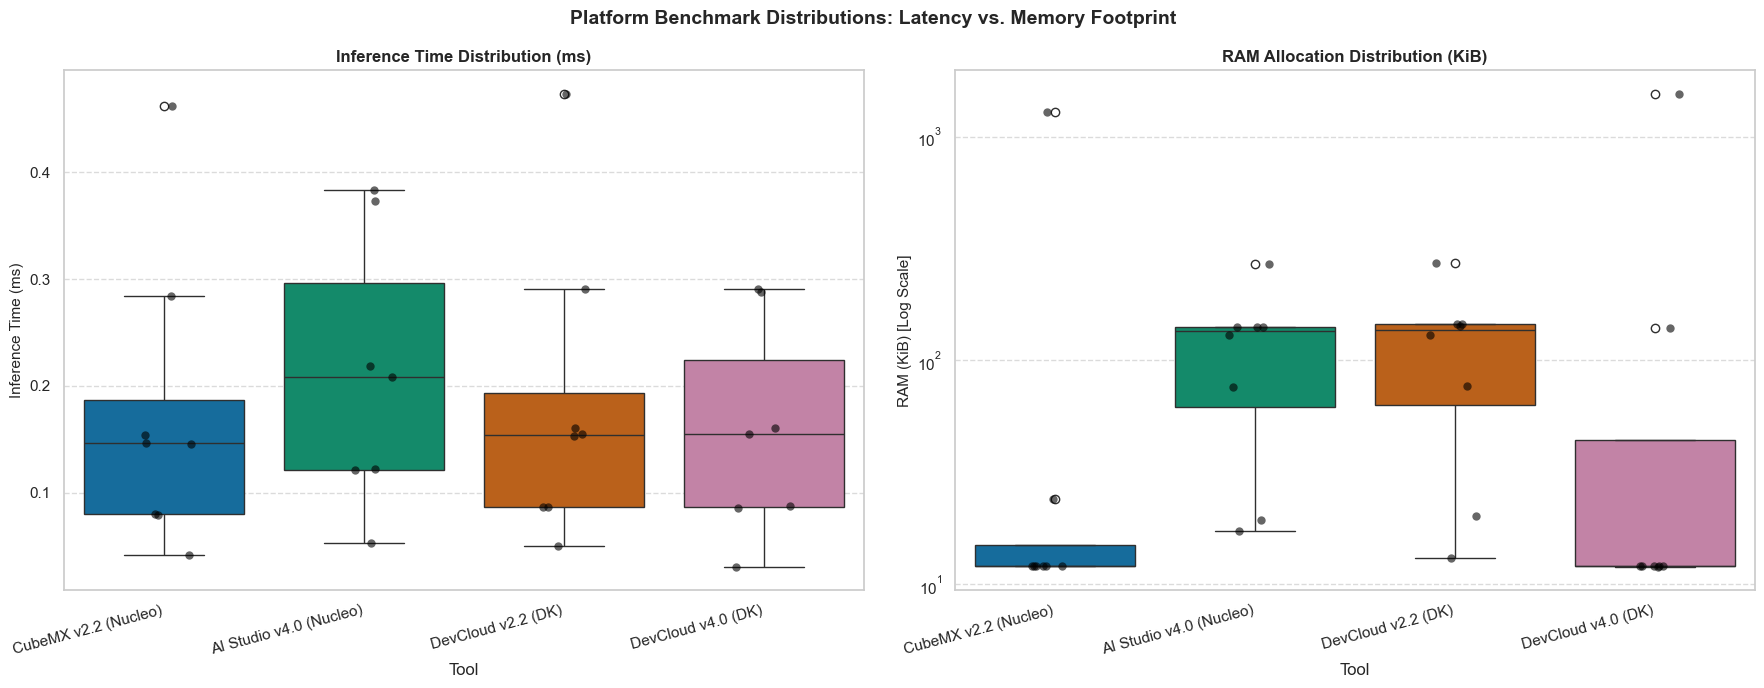

In [8]:
# Compute detailed statistics for successful runs
stats_time_list, stats_ram_list = [], []

for tool, df in dfs_base.items():
    times = df['Inference Time (ms)'].dropna()
    rams  = df['RAM Usage (KiB)'].dropna()

    t_stats = times.describe()
    t_stats['variance']          = times.var()
    t_stats['90%']               = times.quantile(0.9)
    t_stats['success_rate (%)']  = (df['Inference Time (ms)'].notna().sum() / len(df)) * 100
    stats_time_list.append(t_stats.rename(tool))

    r_stats = rams.describe()
    r_stats['variance'] = rams.var()
    r_stats['90%']      = rams.quantile(0.9)
    stats_ram_list.append(r_stats.rename(tool))

df_stats_time = pd.concat(stats_time_list, axis=1).reindex(columns=col_order_tools)
df_stats_ram  = pd.concat(stats_ram_list, axis=1).reindex(columns=col_order_tools)

stats_rename = {
    'count': 'Successful Runs',
    'mean':  'Mean (avg)',
    'std':   'Std Dev',
    'variance': 'Variance',
    'min':   'Minimum',
    '25%':   '25th Percentile (P25)',
    '50%':   'Median (P50)',
    '75%':   '75th Percentile (P75)',
    '90%':   '90th Percentile (P90)',
    'max':   'Maximum',
    'success_rate (%)': 'Success Rate (%)'
}

df_stats_time.rename(index=stats_rename, inplace=True)
df_stats_ram.rename(index=stats_rename, inplace=True)

html_st = df_stats_time.style.set_caption("Latency (Inference Time) Summary Statistics").format(
    precision=4).set_properties(**{'text-align': 'center'}).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]}]).to_html()
html_sr = df_stats_ram.style.set_caption("RAM Memory Allocation Summary Statistics").format(
    precision=2).set_properties(**{'text-align': 'center'}).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]}]).to_html()

display_html(html_st, raw=True)
display_html("<br>", raw=True)
display_html(html_sr, raw=True)

# Prepare flattened RAM list
ram_plot_data = []
for tool, df in dfs_base.items():
    for _, row in df.iterrows():
        ram_plot_data.append({'Tool': tool, 'RAM Usage (KiB)': row['RAM Usage (KiB)']})
df_ram_all = pd.DataFrame(ram_plot_data)

# Side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.boxplot(data=df_all.dropna(subset=['Inference Time (ms)']),
            x='Tool', y='Inference Time (ms)', ax=axes[0],
            palette=COLOR_MAP, order=col_order_tools)
sns.stripplot(data=df_all.dropna(subset=['Inference Time (ms)']),
              x='Tool', y='Inference Time (ms)', ax=axes[0],
              color='black', alpha=0.6, size=6, jitter=0.15, order=col_order_tools)
axes[0].set_title('Inference Time Distribution (ms)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Inference Time (ms)', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.boxplot(data=df_ram_all.dropna(subset=['RAM Usage (KiB)']),
            x='Tool', y='RAM Usage (KiB)', ax=axes[1],
            palette=COLOR_MAP, order=col_order_tools)
sns.stripplot(data=df_ram_all.dropna(subset=['RAM Usage (KiB)']),
              x='Tool', y='RAM Usage (KiB)', ax=axes[1],
              color='black', alpha=0.6, size=6, jitter=0.15, order=col_order_tools)
axes[1].set_title('RAM Allocation Distribution (KiB)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('RAM (KiB) [Log Scale]', fontsize=11)
axes[1].set_yscale('log')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Platform Benchmark Distributions: Latency vs. Memory Footprint',
             fontweight='bold', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/12_latency_vs_ram_distributions.png', dpi=300)
plt.show()

## 7. Flash Memory Usage across Platforms
Flash memory holds the model weights after quantization. While all compilers target the same model, small differences in kernel packing and padding can result in slightly different Flash footprints.
This plot shows the **actual Flash Usage (KiB)** measured on hardware for each layer and platform.

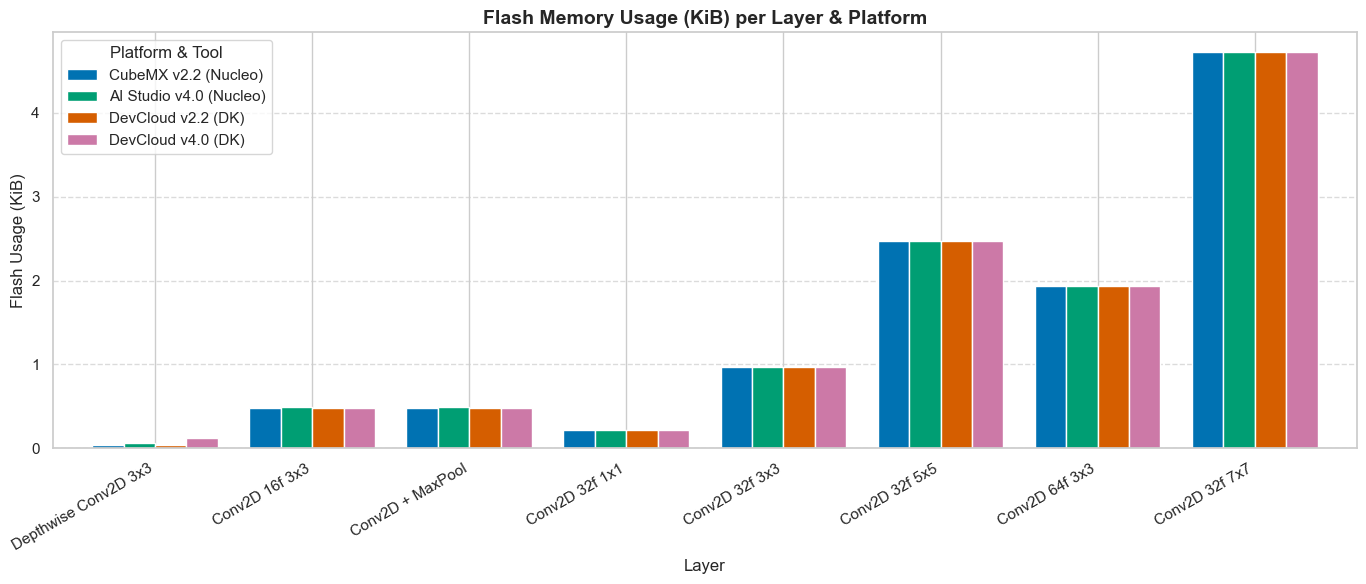

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,0.04,0.06,0.04,0.13
Conv2D 16f 3x3,0.48,0.49,0.48,0.48
Conv2D + MaxPool,0.48,0.49,0.48,0.48
Conv2D 32f 1x1,0.22,0.22,0.22,0.22
Conv2D 32f 3x3,0.97,0.97,0.97,0.97
Conv2D 32f 5x5,2.47,2.47,2.47,2.47
Conv2D 64f 3x3,1.94,1.94,1.94,1.94
Conv2D 32f 7x7,4.72,4.72,4.72,4.72


In [9]:
# Build Flash data
flash_data = []
for m in all_models:
    row_data = {'Model': get_clean_name(m)}
    for tool_name, df in dfs_base.items():
        row_match = df[df['Model Name'] == m]
        row_data[tool_name] = row_match.iloc[0]['Flash Usage (KiB)'] if not row_match.empty else np.nan
    flash_data.append(row_data)

df_flash = pd.DataFrame(flash_data).set_index('Model')
df_flash  = df_flash.reindex(columns=col_order_tools)
df_flash  = df_flash.reindex([m for m in model_order if m in df_flash.index])

colors_fl = [COLOR_MAP[c] for c in df_flash.columns]
ax = df_flash.plot(kind='bar', figsize=(14, 6), width=0.8, color=colors_fl)
ax.set_title('Flash Memory Usage (KiB) per Layer & Platform', fontweight='bold', fontsize=14)
ax.set_ylabel('Flash Usage (KiB)', fontsize=12)
ax.set_xlabel('Layer', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Platform & Tool', frameon=True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/14_flash_usage_bar.png', dpi=300)
plt.show()

# Table
styled_flash = df_flash.style.set_caption("Actual Flash Usage (KiB) — Hardware Measured").format(
    precision=2).set_properties(**{'text-align': 'center'}).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1a5276'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]}])
display(styled_flash)

## 8. RAM Estimation Accuracy: Compiler Error (Δ%)
This analysis quantifies **how far off** the compiler's RAM predictions are from the actual hardware measurements.

$$\Delta\% = \frac{\text{Actual} - \text{Estimated}}{\text{Estimated}} \times 100$$

- Positive values → compiler **under-estimates** (risky: may cause OOM at runtime).
- Negative values → compiler **over-estimates** (conservative, wastes predicted budget).
- Values near 0 → accurate prediction.

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,+0.0%,+44.5%,-45.5%,+0.0%
Conv2D 16f 3x3,+0.0%,+534.6%,+542.3%,+0.0%
Conv2D + MaxPool,+0.0%,+60.6%,+68.2%,+0.0%
Conv2D 32f 1x1,+0.0%,-7.0%,+983.5%,+0.0%
Conv2D 32f 3x3,+0.0%,+1067.2%,+1082.7%,+0.0%
Conv2D 32f 5x5,+0.0%,+1068.8%,+1109.2%,+0.0%
Conv2D 64f 3x3,+0.0%,+2128.0%,+2159.0%,+0.0%
Conv2D 32f 7x7,+0.0%,-90.9%,-88.7%,+0.1%


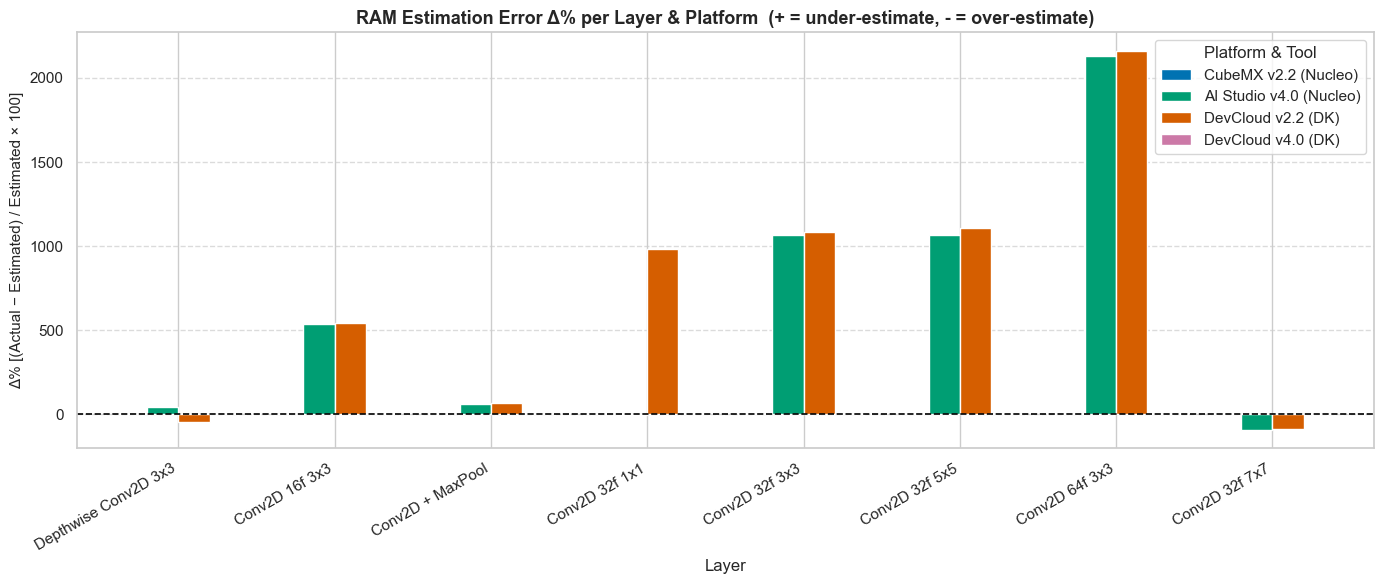

In [10]:
# RAM delta % = (actual - estimated) / estimated * 100
delta_data = []
for m in all_models:
    clean_m   = get_clean_name(m)
    row_data  = {'Model': clean_m}
    for tool in col_order_tools:
        df_e = dfs_est[tool]
        df_a = dfs_base[tool]
        est_row = df_e[df_e['Model Name'] == m]
        act_row = df_a[df_a['Model Name'] == m]
        if not est_row.empty and not act_row.empty:
            est = pd.to_numeric(est_row.iloc[0]['Estimated RAM Usage (KiB)'], errors='coerce')
            act = pd.to_numeric(act_row.iloc[0]['RAM Usage (KiB)'],           errors='coerce')
            row_data[tool] = ((act - est) / est * 100) if (est and est != 0) else np.nan
        else:
            row_data[tool] = np.nan
    delta_data.append(row_data)

df_ram_delta = pd.DataFrame(delta_data).set_index('Model')
df_ram_delta = df_ram_delta.reindex(columns=col_order_tools)
df_ram_delta = df_ram_delta.reindex([m for m in model_order if m in df_ram_delta.index])

# Table with color-coding
styled_delta = df_ram_delta.style.set_caption("RAM Estimation Error Δ% (positive = under-estimate)").format(
    "{:+.1f}%").set_properties(**{'text-align': 'center'}).background_gradient(
    cmap='RdYlGn_r', axis=None).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#922b21'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]}])
display(styled_delta)

# Grouped bar plot
colors_d = [COLOR_MAP[c] for c in df_ram_delta.columns]
ax = df_ram_delta.plot(kind='bar', figsize=(14, 6), width=0.8, color=colors_d)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_title('RAM Estimation Error Δ% per Layer & Platform  (+ = under-estimate, - = over-estimate)', fontweight='bold', fontsize=13)
ax.set_ylabel('Δ% [(Actual − Estimated) / Estimated × 100]', fontsize=11)
ax.set_xlabel('Layer', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Platform & Tool', frameon=True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/15_ram_estimation_error_delta.png', dpi=300)
plt.show()

## 9. Computational Throughput: MACC/ms
Raw inference time alone does not reveal how *efficiently* the NPU executes operations.
**Throughput** (MACC per millisecond) normalises by complexity:

$$\text{Throughput} = \frac{\text{MACC}}{\text{Inference Time (ms)}}$$

A higher value means the platform executes more multiply-accumulate operations per unit time, independently of model size. This metric reveals which platform is inherently faster at number crunching.

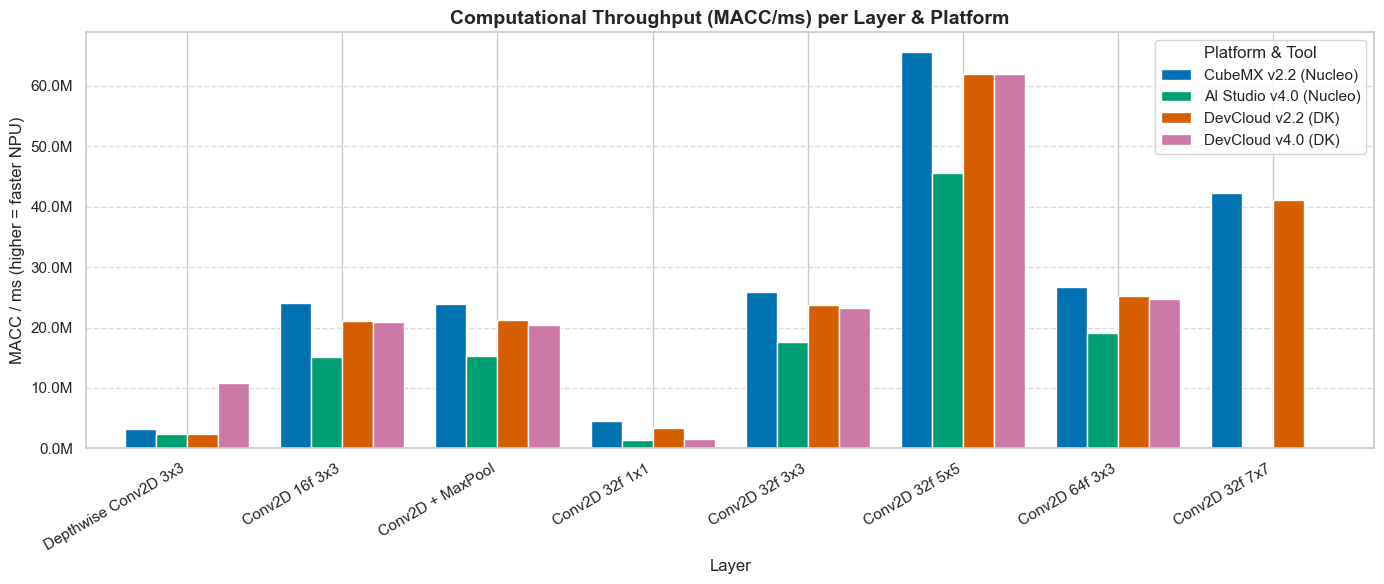

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,"3,218,357","2,318,547","2,457,660","10,900,645"
Conv2D 16f 3x3,"24,057,722","15,041,180","21,092,230","20,956,279"
Conv2D + MaxPool,"23,961,800","15,300,893","21,280,552","20,480,000"
Conv2D 32f 1x1,"4,488,986","1,405,684","3,426,928","1,592,889"
Conv2D 32f 3x3,"25,857,959","17,644,462","23,677,729","23,254,710"
Conv2D 32f 5x5,"65,536,208","45,486,320","61,872,696","61,872,497"
Conv2D 64f 3x3,"26,768,451","19,164,742","25,223,698","24,773,058"
Conv2D 32f 7x7,"42,272,208",nan,"41,012,025",nan


In [11]:
# MACC / ms throughput
tput_data = []
for m in all_models:
    clean_m  = get_clean_name(m)
    row_data = {'Model': clean_m}
    for tool, df in dfs_base.items():
        row_match = df[df['Model Name'] == m]
        if not row_match.empty:
            macc = pd.to_numeric(row_match.iloc[0]['MACC'], errors='coerce')
            t_ms = pd.to_numeric(row_match.iloc[0]['Inference Time (ms)'], errors='coerce')
            row_data[tool] = (macc / t_ms) if (t_ms and t_ms > 0) else np.nan
        else:
            row_data[tool] = np.nan
    tput_data.append(row_data)

df_tput = pd.DataFrame(tput_data).set_index('Model')
df_tput = df_tput.reindex(columns=col_order_tools)
df_tput = df_tput.reindex([m for m in model_order if m in df_tput.index])

colors_tp = [COLOR_MAP[c] for c in df_tput.columns]
ax = df_tput.plot(kind='bar', figsize=(14, 6), width=0.8, color=colors_tp)
ax.set_title('Computational Throughput (MACC/ms) per Layer & Platform',
             fontweight='bold', fontsize=14)
ax.set_ylabel('MACC / ms (higher = faster NPU)', fontsize=12)
ax.set_xlabel('Layer', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Platform & Tool', frameon=True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/16_throughput_macc_per_ms.png', dpi=300)
plt.show()

# Table
styled_tput = df_tput.style.set_caption("Throughput: MACC/ms (higher = more efficient)").format(
    "{:,.0f}").set_properties(**{'text-align': 'center'}).background_gradient(
    cmap='Greens', axis=None).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#145a32'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]}])
display(styled_tput)

## 10. Relative Speedup vs. CubeMX v2.2 (Baseline Reference)
**CubeMX v2.2 (Nucleo)** is used as the reference platform. Speedup is defined as:

$$\text{Speedup} = \frac{t_{\text{CubeMX}}}{t_{\text{Platform}}}$$

- Values **> 1** → platform is **faster** than CubeMX.
- Values **< 1** → platform is **slower** than CubeMX.
- Displayed as a heatmap for quick visual comparison.

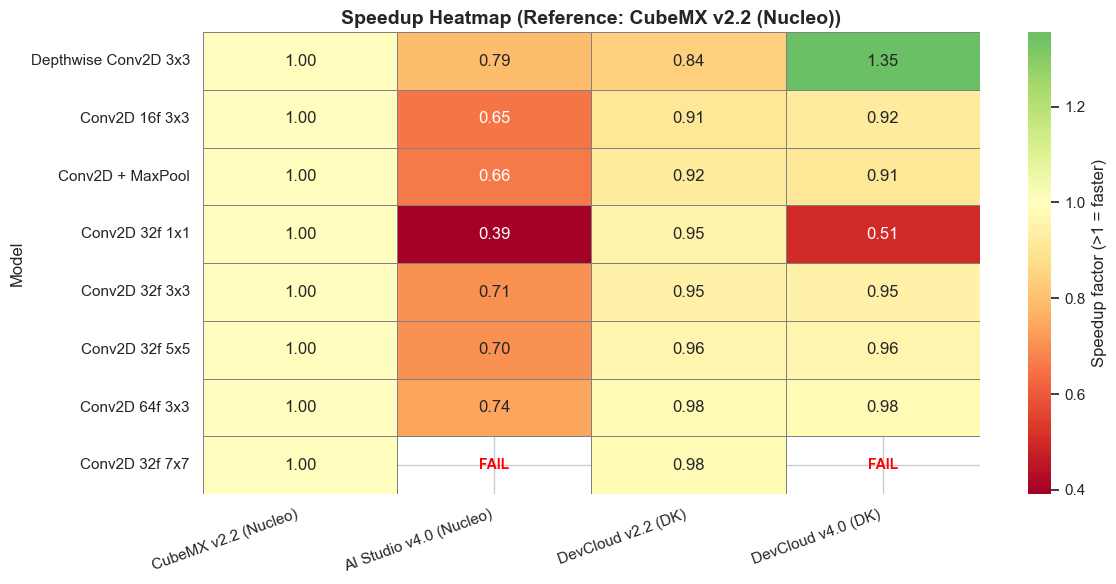

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,1.00×,0.79×,0.84×,1.35×
Conv2D 16f 3x3,1.00×,0.65×,0.91×,0.92×
Conv2D + MaxPool,1.00×,0.66×,0.92×,0.91×
Conv2D 32f 1x1,1.00×,0.39×,0.95×,0.51×
Conv2D 32f 3x3,1.00×,0.71×,0.95×,0.95×
Conv2D 32f 5x5,1.00×,0.70×,0.96×,0.96×
Conv2D 64f 3x3,1.00×,0.74×,0.98×,0.98×
Conv2D 32f 7x7,1.00×,nan×,0.98×,nan×


In [12]:
# Speedup relative to CubeMX v2.2
ref_tool = 'CubeMX v2.2 (Nucleo)'
speedup_data = []

for m in all_models:
    clean_m  = get_clean_name(m)
    row_data = {'Model': clean_m}
    ref_row  = dfs_base[ref_tool][dfs_base[ref_tool]['Model Name'] == m]
    t_ref    = pd.to_numeric(ref_row.iloc[0]['Inference Time (ms)'], errors='coerce') if not ref_row.empty else np.nan
    for tool, df in dfs_base.items():
        if tool == ref_tool:
            row_data[tool] = 1.0
            continue
        row_match = df[df['Model Name'] == m]
        t_val = pd.to_numeric(row_match.iloc[0]['Inference Time (ms)'], errors='coerce') if not row_match.empty else np.nan
        row_data[tool] = (t_ref / t_val) if (t_val and t_val > 0 and not pd.isna(t_ref)) else np.nan
    speedup_data.append(row_data)

df_speedup = pd.DataFrame(speedup_data).set_index('Model')
df_speedup = df_speedup.reindex(columns=col_order_tools)
df_speedup = df_speedup.reindex([m for m in model_order if m in df_speedup.index])

# Heatmap
fig, ax = plt.subplots(figsize=(12, 6))
mask = df_speedup.isna()
sns.heatmap(df_speedup.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
            center=1.0, linewidths=0.5, linecolor='grey',
            mask=mask, ax=ax, cbar_kws={'label': 'Speedup factor (>1 = faster)'})

# Mark FAILs
for r_idx, row in enumerate(df_speedup.index):
    for c_idx, col in enumerate(df_speedup.columns):
        if mask.iloc[r_idx, c_idx]:
            ax.text(c_idx + 0.5, r_idx + 0.5, 'FAIL', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='red')

ax.set_title(f'Speedup Heatmap (Reference: {ref_tool})', fontweight='bold', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/17_speedup_heatmap.png', dpi=300)
plt.show()

# Table
styled_speedup = df_speedup.style.set_caption(
    f"Relative Speedup vs. {ref_tool} (>1 = faster)").format("{:.2f}×").set_properties(
    **{'text-align': 'center'}).background_gradient(
    cmap='RdYlGn', vmin=0.5, vmax=2.0, axis=None).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]}])
display(styled_speedup)

## 11. Scatter Plot: MACC vs. Inference Time
This scatter plot reveals the relationship between **computational complexity (MACC)** and **measured latency**.
An ideal linear relationship would confirm predictable scaling. Deviations (outliers above the trendline) indicate inefficient scheduling, memory bottlenecks, or epoch-partitioning overhead.

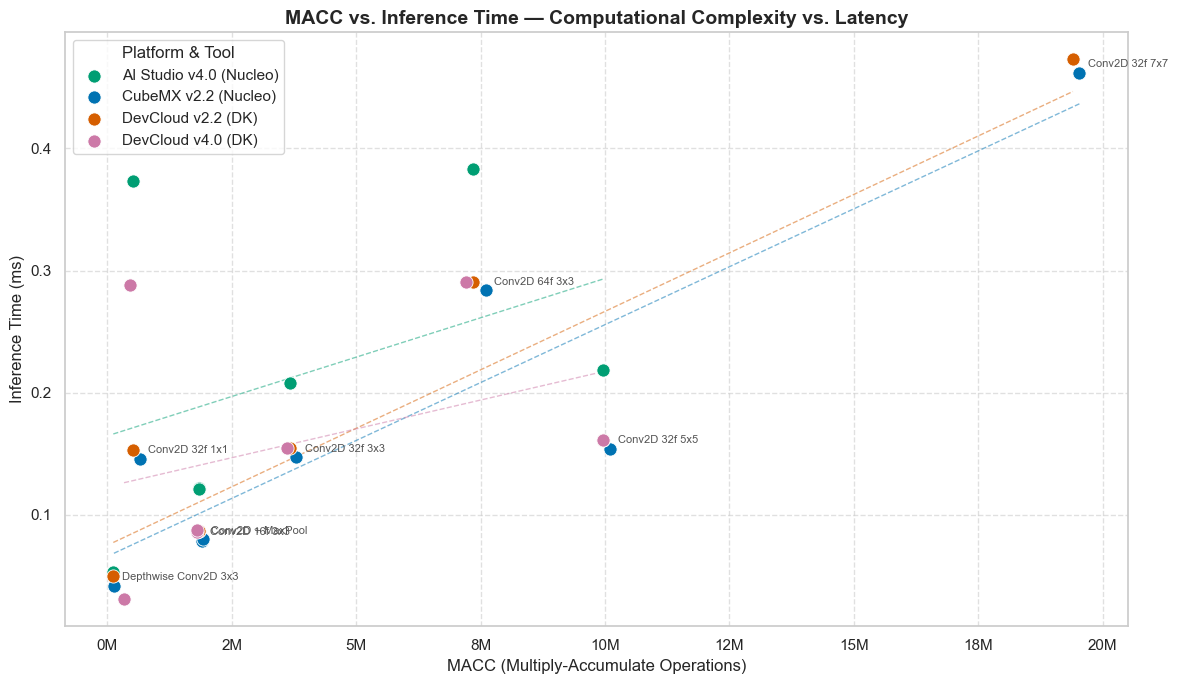

In [13]:
# Scatter MACC vs Inference Time
scatter_data = []
for tool, df in dfs_base.items():
    for _, row in df.iterrows():
        macc = pd.to_numeric(row['MACC'], errors='coerce')
        t_ms = pd.to_numeric(row['Inference Time (ms)'], errors='coerce')
        if not pd.isna(macc) and not pd.isna(t_ms):
            scatter_data.append({
                'Tool':      tool,
                'Model':     get_clean_name(row['Model Name']),
                'MACC':      macc,
                'Inference Time (ms)': t_ms
            })

df_scatter = pd.DataFrame(scatter_data)

fig, ax = plt.subplots(figsize=(12, 7))
for tool, grp in df_scatter.groupby('Tool'):
    ax.scatter(grp['MACC'], grp['Inference Time (ms)'],
               label=tool, color=COLOR_MAP[tool], s=90, edgecolors='white', linewidths=0.6, zorder=3)

# Annotate each point with layer name (use CubeMX as reference)
ref_grp = df_scatter[df_scatter['Tool'] == ref_tool]
for _, row in ref_grp.iterrows():
    ax.annotate(row['Model'], xy=(row['MACC'], row['Inference Time (ms)']),
                xytext=(6, 4), textcoords='offset points', fontsize=8, color='#555')

# Regression line for each tool
for tool, grp in df_scatter.groupby('Tool'):
    if len(grp) > 1:
        z = np.polyfit(grp['MACC'], grp['Inference Time (ms)'], 1)
        p = np.poly1d(z)
        xs = np.linspace(grp['MACC'].min(), grp['MACC'].max(), 200)
        ax.plot(xs, p(xs), linestyle='--', color=COLOR_MAP[tool], alpha=0.5, linewidth=1)

ax.set_title('MACC vs. Inference Time — Computational Complexity vs. Latency',
             fontweight='bold', fontsize=14)
ax.set_xlabel('MACC (Multiply-Accumulate Operations)', fontsize=12)
ax.set_ylabel('Inference Time (ms)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.grid(linestyle='--', alpha=0.6)
ax.legend(title='Platform & Tool', frameon=True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/18_scatter_macc_vs_inference.png', dpi=300)
plt.show()

## 12. Inference Time Heatmap (Layer × Platform)
A normalized heatmap of measured inference times allows immediate visual identification of the fastest platform for each layer type. Values are normalized per row (per layer) so colours reflect relative performance rather than absolute magnitude.

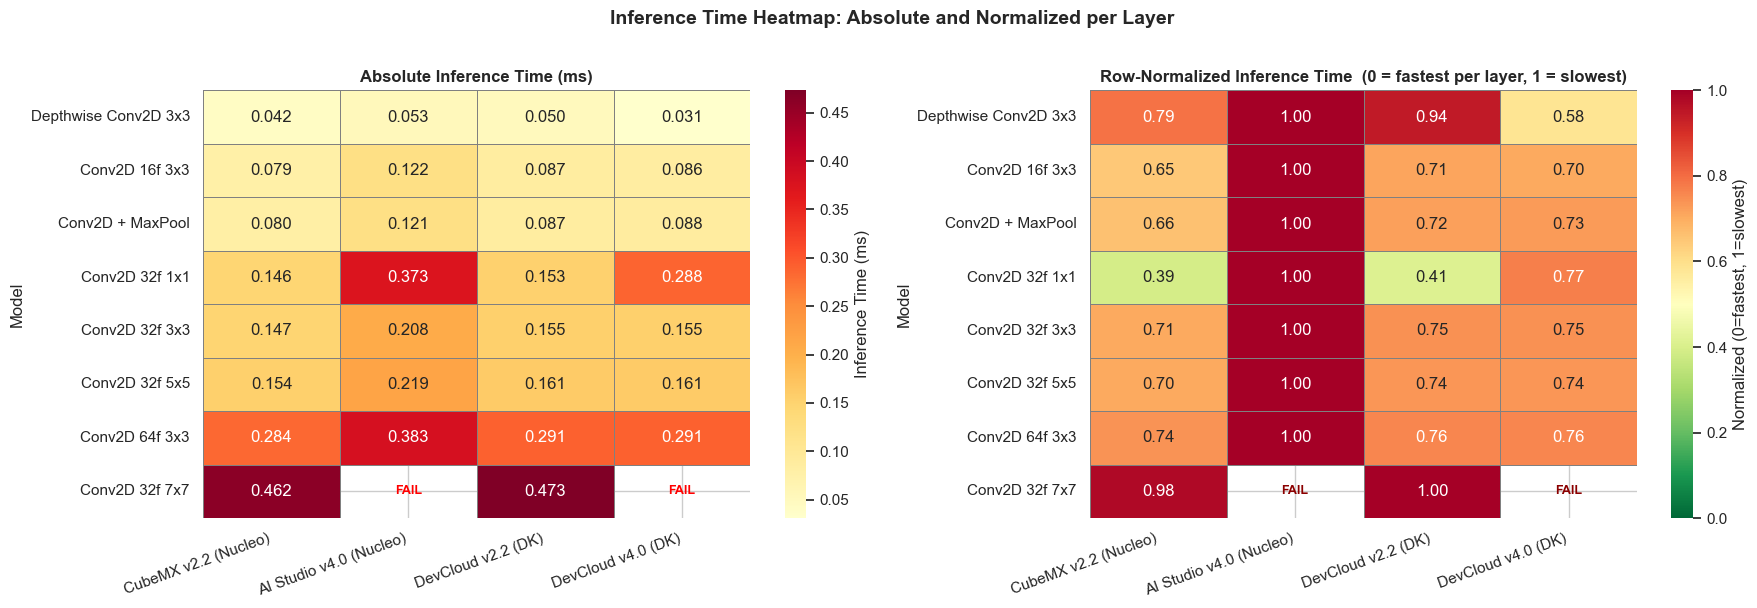

In [14]:
# Heatmap of inference times (normalized per row)
df_heat = df_inference_table.copy().astype(float)

# Row-normalized: 0 = fastest for that layer, 1 = slowest
df_heat_norm = df_heat.div(df_heat.max(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Absolute heatmap
sns.heatmap(df_heat.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='grey', ax=axes[0],
            cbar_kws={'label': 'Inference Time (ms)'},
            mask=df_heat.isna())
axes[0].set_title('Absolute Inference Time (ms)', fontweight='bold', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Add FAIL annotations on absolute map
for r_idx, row in enumerate(df_heat.index):
    for c_idx, col in enumerate(df_heat.columns):
        if pd.isna(df_heat.iloc[r_idx, c_idx]):
            axes[0].text(c_idx + 0.5, r_idx + 0.5, 'FAIL', ha='center', va='center',
                         fontsize=9, fontweight='bold', color='red')

# Row-normalized heatmap
sns.heatmap(df_heat_norm.astype(float), annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='grey', ax=axes[1],
            vmin=0, vmax=1,
            cbar_kws={'label': 'Normalized (0=fastest, 1=slowest)'},
            mask=df_heat_norm.isna())
axes[1].set_title('Row-Normalized Inference Time  (0 = fastest per layer, 1 = slowest)',
                   fontweight='bold', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

for r_idx, row in enumerate(df_heat_norm.index):
    for c_idx, col in enumerate(df_heat_norm.columns):
        if pd.isna(df_heat_norm.iloc[r_idx, c_idx]):
            axes[1].text(c_idx + 0.5, r_idx + 0.5, 'FAIL', ha='center', va='center',
                         fontsize=9, fontweight='bold', color='darkred')

plt.suptitle('Inference Time Heatmap: Absolute and Normalized per Layer',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/19_inference_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Memory Efficiency: RAM per MACC (KiB / MMACC)
This metric shows how much RAM is consumed per million MAC operations (MMACC).
Layers with a **high RAM/MACC** ratio are memory-bound rather than compute-bound, suggesting that architecture or partitioning choices dominate memory overhead more than raw operation count.

$$\text{RAM Efficiency} = \frac{\text{RAM (KiB)}}{\text{MACC} / 10^6}$$

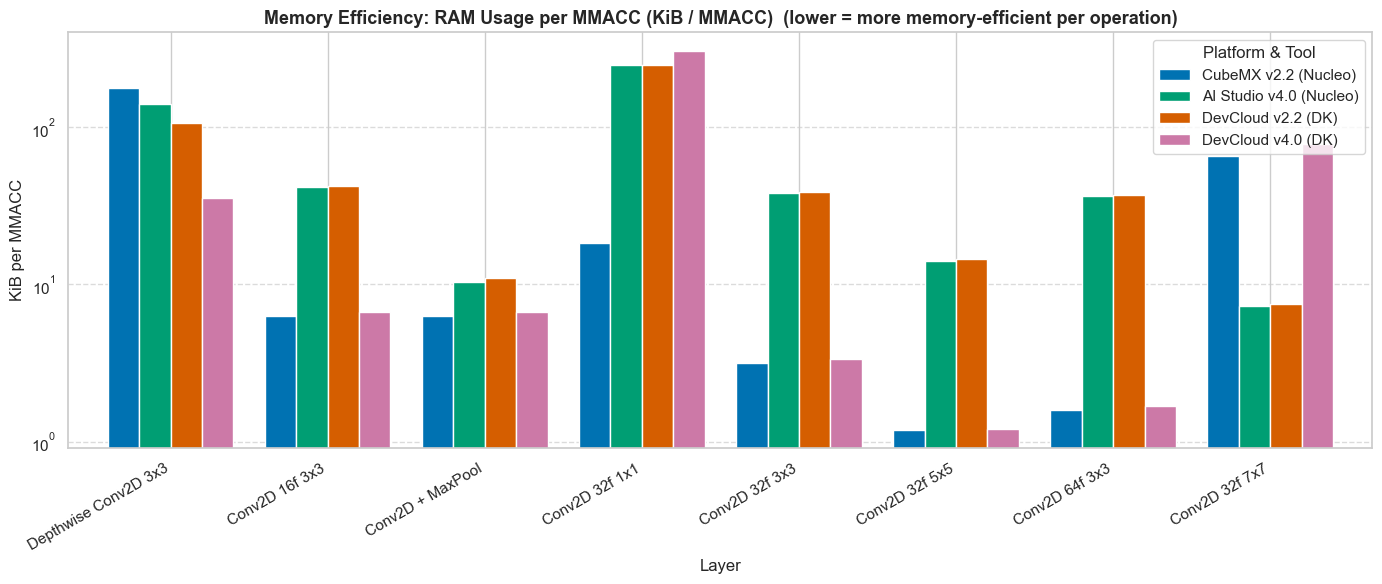

In [15]:
# RAM per MMACC
ram_eff_data = []
for m in all_models:
    clean_m  = get_clean_name(m)
    row_data = {'Model': clean_m}
    for tool, df in dfs_base.items():
        row_match = df[df['Model Name'] == m]
        if not row_match.empty:
            ram  = pd.to_numeric(row_match.iloc[0]['RAM Usage (KiB)'],   errors='coerce')
            macc = pd.to_numeric(row_match.iloc[0]['MACC'], errors='coerce')
            row_data[tool] = (ram / (macc / 1e6)) if (macc and macc > 0) else np.nan
        else:
            row_data[tool] = np.nan
    ram_eff_data.append(row_data)

df_ram_eff = pd.DataFrame(ram_eff_data).set_index('Model')
df_ram_eff = df_ram_eff.reindex(columns=col_order_tools)
df_ram_eff = df_ram_eff.reindex([m for m in model_order if m in df_ram_eff.index])

colors_re = [COLOR_MAP[c] for c in df_ram_eff.columns]
ax = df_ram_eff.plot(kind='bar', figsize=(14, 6), width=0.8, color=colors_re)
ax.set_title('Memory Efficiency: RAM Usage per MMACC (KiB / MMACC)  (lower = more memory-efficient per operation)', fontweight='bold', fontsize=13)
ax.set_ylabel('KiB per MMACC', fontsize=12)
ax.set_xlabel('Layer', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yscale('log')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Platform & Tool', frameon=True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/20_ram_efficiency.png', dpi=300)
plt.show()